<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">

# Procesamiento de Lenguaje Natural
## Desafío 4: Bot conversacional con encoder-decoder

**Alumna:** Maira Daniela Ferrari

**Dataset:** ConvAI2 (Conversational Intelligence Challenge 2)

### Consigna
1. Utilizar datos del challenge ConvAI2 de conversaciones en inglés.
2. Realizar el preprocesamiento necesario para obtener los word2idx, secuencias paddeadas y targets.
3. Preparar embeddings pre-entrenados (GloVe) para las secuencias de entrada.
4. Entrenar un modelo encoder-decoder LSTM.
5. Realizar inferencia separando encoder y decoder, y experimentar con el bot.

## 1. Imports y configuración

In [16]:
import re
import json
import os
import pickle
import logging
from pathlib import Path
from io import StringIO

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences, to_categorical
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding
from tensorflow.keras.models import Model

print(f"TensorFlow: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.20.0
GPU disponible: []


## 2. Carga del dataset

Usamos los datos del ConvAI2 (Conversational Intelligence Challenge 2), que contiene conversaciones en inglés entre personas. La idea es armar pares pregunta-respuesta para entrenar un bot.

In [17]:
!pip install --upgrade --no-cache-dir gdown --quiet

DEPRECATION: Python 2.7 reached the end of its life on January 1st, 2020. Please upgrade your Python as Python 2.7 is no longer maintained. pip 21.0 will drop support for Python 2.7 in January 2021. More details about Python 2 support in pip can be found at https://pip.pypa.io/en/latest/development/release-process/#python-2-support pip 21.0 will remove support for this functionality.


In [18]:
import gdown

if not os.path.exists('data_volunteers.json'):
    url = 'https://drive.google.com/uc?id=1awUxYwImF84MIT5-jCaYAPe2QwSgS1hN&export=download'
    gdown.download(url, 'data_volunteers.json', quiet=False)
else:
    print("Dataset ya descargado")

with open('data_volunteers.json') as f:
    data = json.load(f)

print(f"Cantidad de conversaciones: {len(data)}")
print(f"Campos disponibles: {data[0].keys()}")

Dataset ya descargado
Cantidad de conversaciones: 1111
Campos disponibles: dict_keys(['dialog', 'start_time', 'end_time', 'bot_profile', 'user_profile', 'eval_score', 'profile_match', 'participant1_id', 'participant2_id'])


In [19]:
# Veamos un ejemplo de diálogo
for i, turn in enumerate(data[0]['dialog'][:6]):
    speaker = "A" if i % 2 == 0 else "B"
    print(f"  {speaker}: {turn['text']}")

  A: hi there


## 3. Preprocesamiento

Armamos pares input/output a partir de los turnos consecutivos del diálogo. Cada turno se empareja con el siguiente como pregunta-respuesta.

Para el decoder necesitamos dos versiones de la respuesta:
- **decoder_input**: con token `<sos>` al inicio (lo que el decoder recibe como entrada)
- **decoder_output**: con token `<eos>` al final (lo que el decoder tiene que predecir)

In [20]:
MAX_LEN = 30  # largo máximo en caracteres (filtro del template)

def clean_text(txt):
    """Limpia y normaliza texto."""
    txt = txt.lower()
    txt = txt.replace("'d", " had")
    txt = txt.replace("'s", " is")
    txt = txt.replace("'m", " am")
    txt = txt.replace("don't", "do not")
    txt = txt.replace("can't", "can not")
    txt = txt.replace("won't", "will not")
    txt = txt.replace("'re", " are")
    txt = txt.replace("'ve", " have")
    txt = txt.replace("'ll", " will")
    txt = re.sub(r'\W+', ' ', txt)
    return txt.strip()

input_sentences = []
output_sentences = []       # con <eos>
output_sentences_inputs = [] # con <sos>

for conversation in data:
    dialog = conversation['dialog']
    for i in range(len(dialog) - 1):
        question = clean_text(dialog[i]['text'])
        answer = clean_text(dialog[i + 1]['text'])

        # Filtrar pares demasiado largos
        if len(question) >= MAX_LEN or len(answer) >= MAX_LEN:
            continue

        input_sentences.append(question)
        output_sentences.append(answer + ' <eos>')
        output_sentences_inputs.append('<sos> ' + answer)

print(f"Pares de entrenamiento: {len(input_sentences):,}")
print(f"\nEjemplo:")
print(f"  Input:          {input_sentences[0]}")
print(f"  Decoder input:  {output_sentences_inputs[0]}")
print(f"  Decoder output: {output_sentences[0]}")

Pares de entrenamiento: 6,258

Ejemplo:
  Input:          hello
  Decoder input:  <sos> hi how are you
  Decoder output: hi how are you <eos>


### Tokenización

Usamos tokenizadores separados para input y output. Para el output necesitamos que los tokens `<sos>` y `<eos>` estén en el vocabulario, así que ajustamos los filtros del tokenizador para no eliminar `<` y `>`.

In [21]:
MAX_VOCAB_SIZE = 8000

# Tokenizador del input (preguntas)
input_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
input_tokenizer.fit_on_texts(input_sentences)
input_sequences = input_tokenizer.texts_to_sequences(input_sentences)

word2idx_inputs = input_tokenizer.word_index
num_words_input = min(len(word2idx_inputs) + 1, MAX_VOCAB_SIZE)
max_input_len = max(len(seq) for seq in input_sequences)

print(f"Vocabulario input: {len(word2idx_inputs)} palabras")
print(f"Secuencia input más larga: {max_input_len} tokens")

# Tokenizador del output (respuestas)
# Sacamos <> de los filtros para preservar <sos> y <eos>
output_tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE,
    filters='!"#$%&()*+,-./:;=?@[\\]^_`{|}~\t\n'
)
output_tokenizer.fit_on_texts(['<sos>', '<eos>'] + output_sentences + output_sentences_inputs)
output_sequences = output_tokenizer.texts_to_sequences(output_sentences)
output_input_sequences = output_tokenizer.texts_to_sequences(output_sentences_inputs)

word2idx_outputs = output_tokenizer.word_index
num_words_output = min(len(word2idx_outputs) + 1, MAX_VOCAB_SIZE)
max_output_len = max(len(seq) for seq in output_sequences)

print(f"\nVocabulario output: {len(word2idx_outputs)} palabras")
print(f"Secuencia output más larga: {max_output_len} tokens")

Vocabulario input: 1862 palabras
Secuencia input más larga: 9 tokens

Vocabulario output: 1857 palabras
Secuencia output más larga: 10 tokens


In [22]:
# Padding: pre para encoder (info importante al final), post para decoder (genera desde el inicio)
encoder_input_data = pad_sequences(input_sequences, maxlen=max_input_len, padding='pre')
decoder_input_data = pad_sequences(output_input_sequences, maxlen=max_output_len, padding='post')
decoder_output_data = pad_sequences(output_sequences, maxlen=max_output_len, padding='post')

# One-hot del target para categorical_crossentropy
decoder_targets = to_categorical(decoder_output_data, num_classes=num_words_output)

# Diccionarios inversos para inferencia
idx2word_input = {v: k for k, v in word2idx_inputs.items()}
idx2word_output = {v: k for k, v in word2idx_outputs.items()}

print(f"encoder_input_data shape: {encoder_input_data.shape}")
print(f"decoder_input_data shape: {decoder_input_data.shape}")
print(f"decoder_targets shape:    {decoder_targets.shape}")

encoder_input_data shape: (6258, 9)
decoder_input_data shape: (6258, 10)
decoder_targets shape:    (6258, 10, 1858)


## 4. Embeddings pre-entrenados (GloVe)

Usamos GloVe (50 dimensiones, Twitter corpus) para representar las palabras del input. Esto le da al encoder una representación semántica de entrada sin necesidad de aprenderla desde cero.

Los embeddings del decoder se aprenden durante el entrenamiento, ya que el vocabulario de salida puede diferir del de entrada.

In [23]:
# Descargar embeddings de GloVe (pickle pre-armado de la cátedra)
def is_valid_pickle(path):
    try:
        with open(path, "rb") as f:
            head = f.read(20)
        if b"<html" in head.lower() or b"<!doctype" in head.lower():
            return False
        return True
    except:
        return False

GLOVE_PKL = "gloveembedding.pkl"
GLOVE_DRIVE_ID = "1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94"

if not os.path.exists(GLOVE_PKL) or not is_valid_pickle(GLOVE_PKL):
    if os.path.exists(GLOVE_PKL):
        os.remove(GLOVE_PKL)
    gdown.download(id=GLOVE_DRIVE_ID, output=GLOVE_PKL, quiet=False)
    if not is_valid_pickle(GLOVE_PKL):
        raise ValueError("Descarga fallida, el archivo no es un pickle válido")
    print("Descarga completada")
else:
    print("Embeddings ya descargados")

Embeddings ya descargados


In [24]:
# Clase para cargar embeddings desde pickle
class WordsEmbeddings:
    def __init__(self, pkl_path, n_features):
        max_bytes = 2**28 - 1
        bytes_in = bytearray(0)
        input_size = os.path.getsize(pkl_path)
        with open(pkl_path, 'rb') as f:
            for _ in range(0, input_size, max_bytes):
                bytes_in += f.read(max_bytes)
        self.embeddings = pickle.loads(bytes_in)
        self.n_features = n_features
        index = np.arange(self.embeddings.shape[0])
        self.word2idx = dict(zip(self.embeddings['word'], index))

    def get_embedding(self, word):
        idx = self.word2idx.get(word, -1)
        if idx == -1:
            return None
        return self.embeddings[idx]['embedding']

glove = WordsEmbeddings(GLOVE_PKL, n_features=50)
EMBED_DIM = glove.n_features
print(f"GloVe cargado: {len(glove.word2idx)} palabras, {EMBED_DIM} dimensiones")

GloVe cargado: 1193433 palabras, 50 dimensiones


In [25]:
# Construir embedding matrix para el vocabulario del input
embedding_matrix = np.zeros((num_words_input, EMBED_DIM))
words_not_found = []

for word, idx in word2idx_inputs.items():
    if idx >= num_words_input:
        continue
    vec = glove.get_embedding(word)
    if vec is not None and len(vec) > 0:
        embedding_matrix[idx] = vec
    else:
        words_not_found.append(word)

null_embeddings = np.sum(np.sum(embedding_matrix**2, axis=1) == 0)
print(f"Embedding matrix shape: {embedding_matrix.shape}")
print(f"Palabras sin embedding: {len(words_not_found)} ({null_embeddings} filas nulas)")

Embedding matrix shape: (1863, 50)
Palabras sin embedding: 141 (142 filas nulas)


## 5. Modelo encoder-decoder

Armamos un modelo seq2seq con LSTM usando la API funcional de Keras. El encoder comprime la pregunta en un vector de contexto (estados h y c del LSTM), y el decoder genera la respuesta token a token a partir de ese contexto.

El encoder usa los embeddings de GloVe congelados. El decoder aprende sus propios embeddings durante el entrenamiento.

In [26]:
N_UNITS = 256

# --- Encoder ---
encoder_inputs = Input(shape=(max_input_len,), name='encoder_input')

encoder_embedding = Embedding(
    input_dim=num_words_input,
    output_dim=EMBED_DIM,
    input_length=max_input_len,
    weights=[embedding_matrix],
    trainable=False,
    name='encoder_embedding'
)
encoder_embedded = encoder_embedding(encoder_inputs)

encoder_lstm = LSTM(N_UNITS, return_state=True, name='encoder_lstm')
_, encoder_state_h, encoder_state_c = encoder_lstm(encoder_embedded)
encoder_states = [encoder_state_h, encoder_state_c]

# --- Decoder ---
decoder_inputs = Input(shape=(max_output_len,), name='decoder_input')

decoder_embedding = Embedding(
    input_dim=num_words_output,
    output_dim=N_UNITS,
    input_length=max_output_len,
    name='decoder_embedding'
)
decoder_embedded = decoder_embedding(decoder_inputs)

decoder_lstm = LSTM(N_UNITS, return_sequences=True, return_state=True, name='decoder_lstm')
decoder_outputs, _, _ = decoder_lstm(decoder_embedded, initial_state=encoder_states)

decoder_dense = Dense(num_words_output, activation='softmax', name='decoder_output')
decoder_outputs = decoder_dense(decoder_outputs)

# --- Modelo completo ---
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 9)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 9, 50)     │     93,150 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 10, 256)   │    475,648 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 256),     │    314,368 │ encoder_embeddin… │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 10, 256), │    525,312 │ decoder_embeddin… │
│                     │ (None, 256),      │            │ encoder_lstm[0][… │
│                     │ (None, 256)]      │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_output      │ (None, 10, 1858)  │    477,506 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,885,984 (7.19 MB)

 Trainable params: 1,792,834 (6.84 MB)

 Non-trainable params: 93,150 (363.87 KB)

## 6. Entrenamiento

In [27]:
EN_COLAB = 'COLAB_GPU' in os.environ or 'COLAB_RELEASE_TAG' in os.environ

EPOCHS = 30
BATCH_SIZE = 128

history = model.fit(
    [encoder_input_data, decoder_input_data],
    decoder_targets,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.2
)

Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - accuracy: 0.4464 - loss: 5.0146 - val_accuracy: 0.6278 - val_loss: 2.3002
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.6120 - loss: 2.1717 - val_accuracy: 0.6386 - val_loss: 2.1725
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.6344 - loss: 2.0207 - val_accuracy: 0.6634 - val_loss: 2.0640
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.6710 - loss: 1.8702 - val_accuracy: 0.6835 - val_loss: 1.9598
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.6981 - loss: 1.7193 - val_accuracy: 0.6919 - val_loss: 1.8789
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.7056 - loss: 1.6103 - val_accuracy: 0.7021 - val_loss: 1.8130
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.7207 - loss: 1.5401 - val_accuracy: 0.7092 - val_loss: 1.7702
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.7317 - loss: 1.4808 - val_accuracy: 0.7119 - v

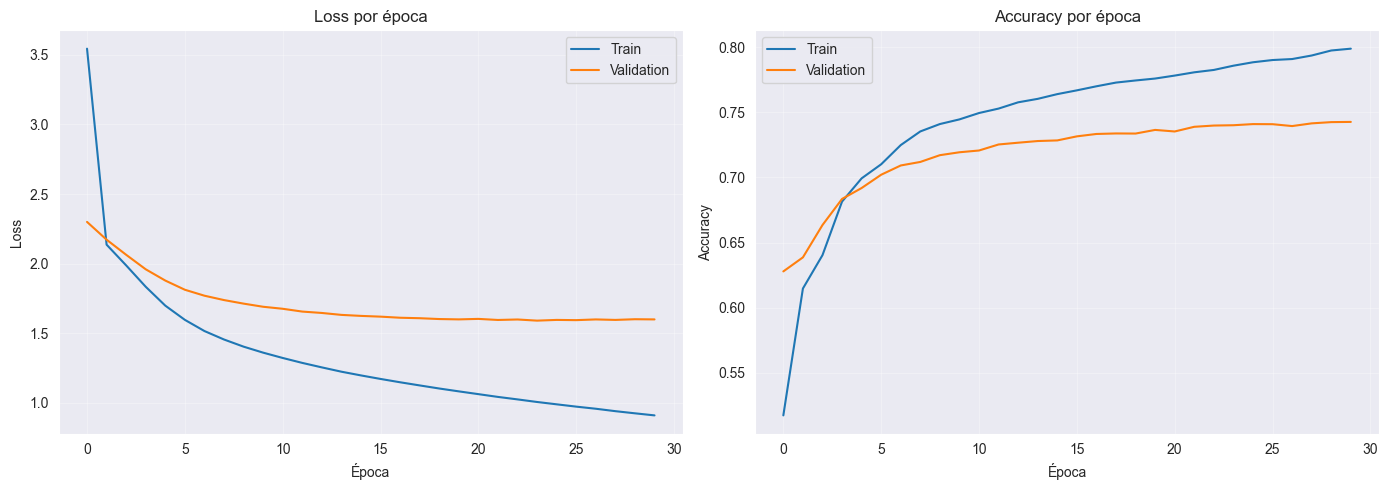

In [36]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['loss'], label='Train')
ax1.plot(history.history['val_loss'], label='Validation')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.set_title('Loss por época')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['accuracy'], label='Train')
ax2.plot(history.history['val_accuracy'], label='Validation')
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy por época')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Las curvas muestran que el modelo aprende bien durante las primeras 10-15 épocas, donde ambas métricas mejoran rápido. Después de ese punto, el training sigue mejorando (loss baja a ~0.9, accuracy sube a ~0.79) pero validación se estanca (loss ~1.6, accuracy ~0.74). Esa separación entre las curvas indica **overfitting leve**: el modelo empieza a memorizar los datos de entrenamiento sin mejorar la generalización a datos nuevos.

Esto es esperable dado el tamaño del dataset (~6K pares) y la arquitectura sin atención, donde toda la información de la pregunta se comprime en un único vector de contexto de 256 dimensiones.

## 7. Inferencia

Para la inferencia, necesitamos separar el encoder y el decoder en modelos independientes. El encoder procesa la pregunta completa y devuelve los estados (h, c). El decoder recibe una palabra a la vez y va generando la respuesta token a token, alimentándose con su propia salida anterior.

In [37]:
# Encoder de inferencia: recibe la pregunta, devuelve estados
encoder_model = Model(encoder_inputs, encoder_states)

# Decoder de inferencia: recibe 1 token + estados anteriores, devuelve predicción + nuevos estados
decoder_state_input_h = Input(shape=(N_UNITS,), name='decoder_state_h')
decoder_state_input_c = Input(shape=(N_UNITS,), name='decoder_state_c')
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

# Input de un solo token
decoder_input_single = Input(shape=(1,), name='decoder_input_single')
decoder_embedded_single = decoder_embedding(decoder_input_single)

decoder_outputs_inf, state_h_inf, state_c_inf = decoder_lstm(
    decoder_embedded_single,
    initial_state=decoder_states_inputs
)
decoder_states_inf = [state_h_inf, state_c_inf]
decoder_outputs_inf = decoder_dense(decoder_outputs_inf)

decoder_model = Model(
    [decoder_input_single] + decoder_states_inputs,
    [decoder_outputs_inf] + decoder_states_inf
)

print("Modelos de inferencia creados")
encoder_model.summary()
decoder_model.summary()

Modelos de inferencia creados


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_embedding (Embedding)   │ (None, 9, 50)          │        93,150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm (LSTM)             │ [(None, 256), (None,   │       314,368 │
│                                 │ 256), (None, 256)]     │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,518 (1.55 MB)

 Trainable params: 314,368 (1.20 MB)

...

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ decoder_input_sing… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 1, 256)    │    475,648 │ decoder_input_si… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_state_h     │ (None, 256)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_state_c     │ (None, 256)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 1, 256),  │    525,312 │ decoder_embeddin… │
│                     │ (None, 256),      │            │ decoder_state_h[… │
│                     │ (None, 256)]      │            │ decoder_state_c[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_output      │ (None, 1, 1858)   │    477,506 │ decoder_lstm[2][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,478,466 (5.64 MB)

 Trainable params: 1,478,466 (5.64 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
def chat(input_text):
    """Genera una respuesta a partir de un texto de entrada."""
    # Preprocesar input
    cleaned = clean_text(input_text)
    seq = input_tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_input_len, padding='pre')

    # Obtener contexto del encoder
    states = encoder_model.predict(padded, verbose=0)

    # Iniciar decoder con <sos>
    target_token = np.zeros((1, 1))
    target_token[0, 0] = word2idx_outputs['<sos>']

    eos_idx = word2idx_outputs['<eos>']
    response = []

    for _ in range(max_output_len):
        output_tokens, h, c = decoder_model.predict(
            [target_token] + states, verbose=0
        )

        predicted_idx = np.argmax(output_tokens[0, 0, :])

        if predicted_idx == eos_idx:
            break

        if predicted_idx > 0:
            word = idx2word_output.get(predicted_idx, '')
            if word:
                response.append(word)

        # Realimentar: la salida actual es la entrada del siguiente paso
        states = [h, c]
        target_token[0, 0] = predicted_idx

    return ' '.join(response)

### Probando el bot

Veamos cómo responde a algunas preguntas.

In [35]:
test_questions = [
    "hi how are you",
    "what do you do for a living",
    "do you have any hobbies",
    "what is your favorite food",
    "where are you from",
    "do you like music",
    "tell me about yourself",
    "what do you think about movies",
    "do you have pets",
    "nice to meet you",
    "How old are you?",
    "What is your favorite color?"
]

print("=" * 60)
print("CONVERSACIONES CON EL BOT")
print("=" * 60)
for question in test_questions:
    response = chat(question)
    print(f"\n> {question}")
    print(f"  Bot: {response}")
print("\n" + "=" * 60)

CONVERSACIONES CON EL BOT

> hi how are you
  Bot: i am fine

> what do you do for a living
  Bot: i am a student

> do you have any hobbies
  Bot: i like to play video games

> what is your favorite food
  Bot: i like to play video games

> where are you from
  Bot: i am fine

> do you like music
  Bot: i like to play video games

> tell me about yourself
  Bot: i am a teacher i am a teacher

> what do you think about movies
  Bot: i like to play video games

> do you have pets
  Bot: i do not have any pets

> nice to meet you
  Bot: i am fine

> How old are you?
  Bot: i am fine

> What is your favorite color?
  Bot: i like to play video games



## 8. Conclusiones

El modelo encoder-decoder con LSTM funciona como una base para entender la arquitectura seq2seq. El encoder comprime la pregunta en un vector de contexto fijo, y el decoder genera la respuesta a partir de ese vector.

Las respuestas del bot son limitadas porque toda la información de la pregunta pasa por un único vector (cuello de botella del seq2seq). Con un dataset más grande, más épocas, o usando mecanismos de atención (cross attention) se podrían mejorar los resultados. Esto es justamente lo que resuelven los Transformers, reemplazando el vector fijo por mecanismos de atención que conectan directamente el encoder con el decoder.